In [18]:
import pandas as pd

# 1. Carregar os dados limpos (ajuste o nome do arquivo se a Eng. de Dados tiver salvo diferente)
df = pd.read_csv('../data/prf_es_clean.csv')

# 2. Criar a Variável Alvo (Y) - Prever Risco Grave/Fatal
# Se o modelo disser 1, é grave. Se disser 0, é leve/sem vítima.
def classificar_risco(gravidade):
    # ATENÇÃO: Verifique no seu CSV quais são as palavras exatas dessa coluna!
    if gravidade in ['Com Vítimas Fatais', 'Lesões Graves']: 
        return 1 
    else:
        return 0 

df['risco_alto'] = df['classificacao_acidente'].apply(classificar_risco)

# 3. Selecionar as variáveis preditoras (X)
# Essas são as "pistas" que o modelo vai usar para tentar adivinhar a gravidade
features = ['condicao_metereologica', 'fase_dia', 'tipo_pista', 'causa_acidente']
X_categorico = df[features]

# Transformar textos em colunas de 0 e 1 (One-Hot Encoding)
X = pd.get_dummies(X_categorico, drop_first=True)
y = df['risco_alto']


In [19]:
from sklearn.model_selection import train_test_split

# Separando em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treinaremos com {X_train.shape[0]} acidentes.")
print(f"Testaremos o modelo com {X_test.shape[0]} acidentes ocultos.")

Treinaremos com 8101 acidentes.
Testaremos o modelo com 2026 acidentes ocultos.


In [20]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("Iniciando o treinamento dos modelos...")

# --- Modelo 1: Random Forest ---
# class_weight='balanced' avisa o modelo que existem poucos acidentes fatais, para ele prestar mais atenção neles.
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest treinado!")

# --- Modelo 2: XGBoost ---
# Calculando o peso para balancear o XGBoost
peso = (len(y_train) - sum(y_train)) / sum(y_train)
xgb_model = XGBClassifier(scale_pos_weight=peso, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost treinado!")


Iniciando o treinamento dos modelos...
Random Forest treinado!
XGBoost treinado!


In [21]:
from sklearn.metrics import classification_report

print("=== BOLETIM DO RANDOM FOREST ===")
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

print("\n=== BOLETIM DO XGBOOST ===")
y_pred_xgb = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

=== BOLETIM DO RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      1916
           1       0.11      0.48      0.18       110

    accuracy                           0.76      2026
   macro avg       0.54      0.63      0.52      2026
weighted avg       0.92      0.76      0.82      2026


=== BOLETIM DO XGBOOST ===
              precision    recall  f1-score   support

           0       0.96      0.69      0.80      1916
           1       0.09      0.55      0.16       110

    accuracy                           0.68      2026
   macro avg       0.53      0.62      0.48      2026
weighted avg       0.92      0.68      0.77      2026



In [22]:
import joblib

# Salvar o modelo vencedor na pasta models
caminho_modelo = '../models/modelo_risco_acidente.pkl'
joblib.dump(rf_model, caminho_modelo)

# Salvar também o nome das colunas do X para usar no front-end do Streamlit depois!
joblib.dump(list(X.columns), '../models/colunas_treino.pkl')

print(f"Modelo salvo com sucesso em: {caminho_modelo}")

Modelo salvo com sucesso em: ../models/modelo_risco_acidente.pkl


In [24]:
%pip install matplotlib

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -

=== PARÂMETROS DO MODELO ===
RandomForestClassifier(class_weight='balanced', random_state=42)


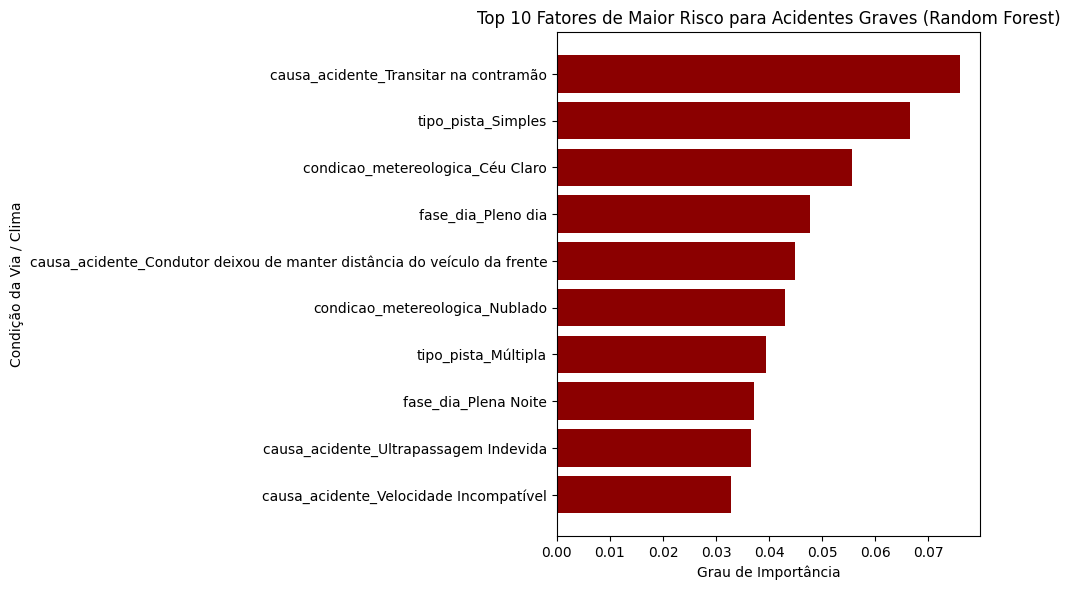

In [25]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# 1. "Descongelar" (Carregar) o modelo e as colunas
modelo_carregado = joblib.load('../models/modelo_risco_acidente.pkl')
colunas = joblib.load('../models/colunas_treino.pkl')

print("=== PARÂMETROS DO MODELO ===")
print(modelo_carregado) # Isso mostra a configuração do algoritmo

# 2. Visualizar o que o modelo aprendeu (Feature Importance)
# Isso pega o peso que o modelo deu para cada coluna na hora de prever o risco
importancias = modelo_carregado.feature_importances_

# 3. Criar uma tabela com as variáveis e seus pesos
tabela_importancia = pd.DataFrame({
    'Variavel': colunas,
    'Importancia': importancias
})

# Ordenar para ver as que mais impactam os acidentes
tabela_importancia = tabela_importancia.sort_values(by='Importancia', ascending=True)

# 4. Gerar um gráfico para a sua apresentação
plt.figure(figsize=(10, 6))
plt.barh(tabela_importancia['Variavel'].tail(10), tabela_importancia['Importancia'].tail(10), color='darkred')
plt.title('Top 10 Fatores de Maior Risco para Acidentes Graves (Random Forest)')
plt.xlabel('Grau de Importância')
plt.ylabel('Condição da Via / Clima')
plt.tight_layout()
plt.show()